# Trimet Data Project

For our project, we decided to work with Trimet data as it sounded interesting and their developer portal have very good documentation for accessing data.

There were 2 static data GIS (Geospatial Data) and GFTS Static (General Transit Feed Specification).  The GIS basically provides an outline of the Transit map such as stop locations, route boundaries, garage locations and GFTS Static mainly contains text files like `stops.txt` `stop_times.txt` which shows how trimet vehicles are planned to move.

The main interesting thing we found that had lots of data was GFTS Realtime.  This logs information on Trimet vehicles in realtime giving back information like location using longitude and latitude, whether the vehicle is delayed or early, what its next stop and previous stop is and sometimes even an approximate of how full the vehicle is.

We worked with this api and built a collector in python to collect data on vehicles every minute.  We ran the collector program as much as we can as you cannot have too much data. The data we recieved from the api is formated in json which we converted into a csv.  In this conversion to csv, we only selected specific columns which sounded interesting in order to minimize the size of the csv file.



## Data Processing

Trimet provided documentation for an api called [/vehicles](https://developer.trimet.org/ws_docs/vehicle_locations_ws.shtml) showing information on what data is collected for a vehicle in real time

Example Json data for 1 vehicle.  This is collected every minute.
After going through the documents in trimet, we've infered on what the data means

*Every minute, it logs about 400 vehicles during the day and almost none at night.*

```
  {
    "routeColor": "61A744",            // Color for route
    "expires": 1760993085102,          // Used by trimet to ensure data up to date
    "signMessage": "FX2 To Gresham",   // display message
    "serviceDate": 1760943600000,      // What day it's serviced on
    "loadPercentage": 15,              // Estimated passenger load (0–100%)
    "latitude": 45.503744191408664,    
    "nextStopSeq": 8,                  // The number of next scheduled stop (8th stop of the day)
    "source": "vm",                    // How the data was recorded
    "type": "bus",                     // Vehicle type (bus, rail, etc.)
    "blockID": 248,                    // Groups multiple trips into blocks
    "signMessageLong": "FX2 Division To Gresham", // More description for message
    "lastLocID": 3397,                 // Stop ID of the last stop location
    "nextLocID": 13732,                
    "locationInScheduleDay": 49133,    // what time bus should be at a certain stop
    "routeSubType": "BRT",             // Subtype (e.g., Bus Rapid Transit)
    "newTrip": false,                  // true if new it's new trip, always false in data
    "longitude": -122.66883380836836,  
    "direction": 0,                    // Route direction (0, 1)
    "inCongestion": false,             // True if vehicle is stopped in traffic
    "routeNumber": 2,                  
    "bearing": 46,                     // Vehicle’s compass (0-360)
    "garage": "POWELL",                
    "tripID": "15644087",              
    "delay": -112,                     // measured in seconds, positive means early
    "extraBlockID": null,              
    "messageCode": 100,                // relates to message display
    "lastStopSeq": 7,                  // the last stop number in sequence of sstop
    "vehicleID": 4531,                 
    "time": 1760992845102,             // Timestamp when this was recorded by vehicle
    "offRoute": false                  // True if vehicle is off its scheduled route
  }
```



## Creating DataFrame from csv

In [164]:
import pandas as pd
df = pd.read_csv('../data/vehicle_positions_full_combined.csv')

## Understanding the data

In [165]:
# format for numbers
pd.options.display.float_format = '{:.2f}'.format
df.head(2)

,bearing,blockID,collection_timestamp,delay,direction,expires,extraBlockID,garage,inCongestion,lastLocID,...,routeNumber,routeSubType,serviceDate,signMessage,signMessageLong,source,time,tripID,type,vehicleID
0,200.00,243,1760817789,-1132,0,1760818026912,NaN,POWELL,False,7642.00,...,2,BRT,1760770800000,FX2 To Gresham,FX2 Division To Gresham,vm,1760817786912,15643905,bus,4530
1,269.00,248,1760817789,-499,1,1760818022926,NaN,POWELL,False,14241.00,...,2,BRT,1760770800000,FX2 To Portland,FX2 Division To Portland,vm,1760817782926,15644364,bus,4528


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467843 entries, 0 to 1467842
Data columns (total 31 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   bearing                1467816 non-null  float64
 1   blockID                1467843 non-null  int64  
 2   collection_timestamp   1467843 non-null  int64  
 3   delay                  1467843 non-null  int64  
 4   direction              1467843 non-null  int64  
 5   expires                1467843 non-null  int64  
 6   extraBlockID           2651 non-null     float64
 7   garage                 1465192 non-null  object 
 8   inCongestion           1149359 non-null  object 
 9   lastLocID              1214279 non-null  float64
 10  lastStopSeq            1214279 non-null  float64
 11  latitude               1467843 non-null  float64
 12  loadPercentage         1011580 non-null  float64
 13  locationInScheduleDay  1467843 non-null  int64  
 14  longitude         

### Data Cleaning and Setting Up

#### Investigate columns to see if information is relevant

Some columns are not straightforward and will need more research to get better understanding.  Potentially could be removed from analyzing if not significant or redundant

#### routeSubType

In [167]:
# Check what RouteSubtype column is:
df['routeSubType'].unique()

array(['BRT', 'Bus', 'Light Rail', 'Shuttle'], dtype=object)

This shows that `routeSubType` gives more specification to vehicle info.  A BRT is "Bus Rapid Transit" and a "Bus" is the smaller old buses both are categorized as `bus` for the `type` column.

#### offRoute

Perhaps we can see if vehicles ever go off route

In [168]:
df['offRoute'].value_counts()

offRoute
False    1460626
True        7217
Name: count, dtype: int64

A small portion goes off route which will be interesting to anlyze later on.

#### Extra Block ID


In [169]:
extra_block_rows = df[df['extraBlockID'].notna()]

# count where extraBlockID = blockID
same = (df['extraBlockID'] == df['blockID']).sum()
# count how many extrablocks there are
diff = df['extraBlockID'].notna().sum()

print(f"Extrablock id same as block id: {same}")
print(f"Total extrablock ids : {diff}")


Extrablock id same as block id: 2651
Total extrablock ids : 2651


From the above code, we can see extrablockid and blockid is always the same.  So it might just be redundant information.

Checking more columns if they are relevant

In [170]:
print(df['newTrip'].value_counts())
print(df['offRoute'].value_counts())
print(df['inCongestion'].value_counts())

newTrip
False    1467843
Name: count, dtype: int64
offRoute
False    1460626
True        7217
Name: count, dtype: int64
inCongestion
False    1140500
True        8859
Name: count, dtype: int64


newTrip is always False.

After investigating, we are choosing to drop some columns that might not be used

- expires: used internally to ensure data up to date
- newTrip: likely deprecated since it's always false.  Suppose to show when a bus starts a new trip but maybe our 1 minute interval does not catch it when it was sent.
- serviceDate: redundant, already have that with other columns
- extraBlockID: very rarely used and is always the same as BlockID

There are many other columns in our data sets but as of now we are choosing to keep most of them since they might be of use when building learning models.  If in the future we find more columns irrelevant, they will be removed.

In [171]:
df = df.drop(columns=['expires', 'newTrip', 'serviceDate', 'extraBlockID'])

#### Clean up with Date and Time

The first thing we can do is convert the str objects into date time object and also generate new columns that will help analyzing later on.

Cleaning process:
- Convert `collection_timestamp` and `time` from `str` to `datetime`
- Create `hour` and `day` columns so we can group them later
- Create `delay_minutes` converting `delay` in seconds to minute
- Create an hour decimal so that it can be used to plot as a line graph


In [172]:
df['collection_timestamp'] = pd.to_datetime(df['collection_timestamp'], unit='s', errors='coerce')
df['time'] = pd.to_datetime(df['time'], unit='ms', errors='coerce')

# Get hour of day and the day name
df['hour'] = df['collection_timestamp'].dt.hour
df['day'] = df['collection_timestamp'].dt.day_name()

# Convert delay from seconds to minutes
# df['time_of_day'] = df['collection_timestamp'].dt.time
df['delay_minutes'] = df['delay'] / 60

df['hour_decimal'] = (
    df['collection_timestamp'].dt.hour + 
    df['collection_timestamp'].dt.minute / 60
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467843 entries, 0 to 1467842
Data columns (total 31 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   bearing                1467816 non-null  float64       
 1   blockID                1467843 non-null  int64         
 2   collection_timestamp   1467843 non-null  datetime64[ns]
 3   delay                  1467843 non-null  int64         
 4   direction              1467843 non-null  int64         
 5   garage                 1465192 non-null  object        
 6   inCongestion           1149359 non-null  object        
 7   lastLocID              1214279 non-null  float64       
 8   lastStopSeq            1214279 non-null  float64       
 9   latitude               1467843 non-null  float64       
 10  loadPercentage         1011580 non-null  float64       
 11  locationInScheduleDay  1467843 non-null  int64         
 12  longitude              14678

### Shuttle Vehicles

While working with the collected data, we learned that there are shuttle ADA (Americans with Disabilities Act) vehicles reported by trimet.  These vechiles report delay values over 9000 seconds which really throws off comparisons.  So we will be removing them early on.

In [173]:
df_shuttles = df[df['routeSubType'] == 'Shuttle'].copy()

shuttle_performance = df_shuttles.groupby('routeNumber')['delay_minutes'].agg(['mean', 'std', 'count'])
shuttle_performance = shuttle_performance.sort_values(by='std', ascending=False)

print(shuttle_performance)

             mean   std  count
routeNumber                   
98           8.95 27.37   7562


The standard deviation for shuttle delay is a crazy high number which most certainly will throw off analysis so we will be seperating shuttle buses for now.

In [174]:
# Before removing shuttles:
delay_performance_old = df['delay_minutes'].agg(['mean', 'std', 'count'])
print('Before removing shuttles')
print(delay_performance_old)

df = df[df['routeSubType'] != 'Shuttle'].copy()
delay_performance = df['delay_minutes'].agg(['mean', 'std', 'count'])
print("After removing")
print(delay_performance)


Before removing shuttles
mean         -1.83
std           5.54
count   1467843.00
Name: delay_minutes, dtype: float64
After removing
mean         -1.89
std           5.14
count   1460281.00
Name: delay_minutes, dtype: float64


In [175]:
print(f'std dropped from {delay_performance_old['std']:.2f} to {delay_performance['std']:.2f}')
rows_dropped = delay_performance_old['count'] - delay_performance['count']
print(f'This is from dropping only {rows_dropped} rows out of {delay_performance_old['count']} rows which shows how impactful it is')


std dropped from 5.54 to 5.14
This is from dropping only 7562.0 rows out of 1467843.0 rows which shows how impactful it is


### Checking for outliers

In [176]:
df.describe()

,bearing,blockID,collection_timestamp,delay,direction,lastLocID,lastStopSeq,latitude,loadPercentage,locationInScheduleDay,...,messageCode,nextLocID,nextStopSeq,routeNumber,time,tripID,vehicleID,hour,delay_minutes,hour_decimal
count,1460254.00,1460281.00,1460281,1460281.00,1460281.00,1210750.00,1210750.00,1460281.00,1004457.00,1460281.00,...,1460281.00,1460281.00,1460281.00,1460281.00,1460281,1460281.00,1460281.00,1460281.00,1460281.00,1460281.00
mean,175.30,5188.19,2025-10-21 06:00:55.782950400,-113.33,0.50,7559.42,29.70,45.51,12.12,51429.61,...,613.44,7891.68,24.61,64.49,2025-10-21 06:00:42.878692608,15630706.75,2928.46,13.91,-1.89,14.40
min,0.00,134.00,2025-10-18 20:03:09,-8595.00,0.00,2.00,1.00,45.28,0.00,11977.00,...,13.00,2.00,1.00,1.00,2025-10-18 19:57:06.241000,900717.00,103.00,0.00,-143.25,0.00
25%,90.00,1904.00,2025-10-19 20:37:22,-159.00,0.00,4323.00,11.00,45.49,3.00,37525.00,...,328.00,4620.00,3.00,19.00,2025-10-19 20:37:16.704999936,15650576.00,3030.00,6.00,-2.65,6.12
50%,180.00,5476.00,2025-10-20 20:48:52,-32.00,0.00,8029.00,24.00,45.52,8.00,52070.00,...,641.00,8345.00,17.00,57.00,2025-10-20 20:48:48.488999936,15657616.00,3419.00,16.00,-0.53,16.90
75%,270.00,8740.00,2025-10-22 22:31:46,0.00,1.00,10117.00,43.00,45.53,17.00,62779.00,...,863.00,10649.00,38.00,88.00,2025-10-22 22:31:41.423000064,15664438.00,3933.00,21.00,0.00,21.10
max,359.00,9768.00,2025-10-23 22:02:04,10271.00,1.00,14661.00,133.00,45.64,192.00,97800.00,...,1094.00,14661.00,134.00,293.00,2025-10-23 22:02:04.168000,15672946.00,4531.00,23.00,171.18,23.98
std,102.06,3228.11,NaN,308.31,0.50,4053.96,24.15,0.05,13.83,17352.94,...,320.68,4142.49,24.96,59.29,NaN,625973.97,1417.97,7.71,5.14,7.73


Some obvious concerning outliers:
* the max value for delay is is over 10,000 and min is over 8,000
* max load percentage is over 100

Let's investigate


### Look Into delay column

In [177]:
# Check for bus over 1 hour late or early
hour_early = df[df['delay'] > 3600]
hour_early.head(5)


,bearing,blockID,collection_timestamp,delay,direction,garage,inCongestion,lastLocID,lastStopSeq,latitude,...,signMessageLong,source,time,tripID,type,vehicleID,hour,day,delay_minutes,hour_decimal
43387,294.00,9024,2025-10-18 21:53:08,6897,1,ELMO,NaN,9832.00,37.00,45.52,...,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,228,21,Saturday,114.95,21.88
43388,294.00,9024,2025-10-18 21:53:08,6897,1,ELMO,NaN,9832.00,37.00,45.52,...,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,120,21,Saturday,114.95,21.88
43775,294.00,9024,2025-10-18 21:54:08,6924,1,ELMO,NaN,9832.00,37.00,45.53,...,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,228,21,Saturday,115.40,21.90
43776,294.00,9024,2025-10-18 21:54:08,6924,1,ELMO,NaN,9832.00,37.00,45.53,...,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,120,21,Saturday,115.40,21.90
44161,285.00,9024,2025-10-18 21:55:08,6925,1,ELMO,NaN,9832.00,37.00,45.53,...,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:55.295,15668041,rail,228,21,Saturday,115.42,21.92


In [178]:
hour_late = df[df['delay'] < -3600]
hour_late.head(5)

,bearing,blockID,collection_timestamp,delay,direction,garage,inCongestion,lastLocID,lastStopSeq,latitude,...,signMessageLong,source,time,tripID,type,vehicleID,hour,day,delay_minutes,hour_decimal
38,1.00,605,2025-10-18 20:03:09,-3705,0,CENTER,False,5918.00,37.00,45.58,...,6 M L King JR to Jantzen Beach Via Schmeer Rd,vm,2025-10-18 20:03:03.879,15645429,bus,4212,20,Saturday,-61.75,20.05
98,174.00,3034,2025-10-18 20:03:09,-5520,0,POWELL,False,NaN,NaN,45.44,...,30 Estacada,vm,2025-10-18 20:03:00.796,15652655,bus,3934,20,Saturday,-92.00,20.05
445,70.00,605,2025-10-18 20:05:43,-3700,0,CENTER,False,5932.00,38.00,45.59,...,6 M L King JR to Jantzen Beach Via Schmeer Rd,vm,2025-10-18 20:05:40.733,15645429,bus,4212,20,Saturday,-61.67,20.08
505,174.00,3034,2025-10-18 20:05:43,-5679,0,POWELL,False,NaN,NaN,45.44,...,30 Estacada,vm,2025-10-18 20:05:39.747,15652655,bus,3934,20,Saturday,-94.65,20.08
522,194.00,1434,2025-10-18 20:05:43,-3652,0,POWELL,False,7655.00,19.00,45.50,...,14 Foster Rd to SE 94th Ave,vm,2025-10-18 20:05:40.748,15648455,bus,3754,20,Saturday,-60.87,20.08


### Over 100 Load Percentage

Load percentage should be 0-100 as a fraction.  Let's investigate why there is over 100 for the max value.

In [179]:
bad_load = df[df['loadPercentage'] > 100]
bad_load.head(5)

,bearing,blockID,collection_timestamp,delay,direction,garage,inCongestion,lastLocID,lastStopSeq,latitude,...,signMessageLong,source,time,tripID,type,vehicleID,hour,day,delay_minutes,hour_decimal
36,291.00,1505,2025-10-18 20:03:09,-927,0,CENTER,False,7216.00,43.00,45.52,...,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:03:02.926,15649138,bus,4217,20,Saturday,-15.45,20.05
443,270.00,1505,2025-10-18 20:05:43,-979,0,CENTER,False,4019.00,46.00,45.52,...,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:05:36.820,15649138,bus,4217,20,Saturday,-16.32,20.08
849,270.00,1505,2025-10-18 20:06:43,-998,0,CENTER,False,4016.00,47.00,45.52,...,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:06:38.263,15649138,bus,4217,20,Saturday,-16.63,20.10
1254,270.00,1505,2025-10-18 20:07:43,-1094,0,CENTER,False,4019.00,46.00,45.52,...,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:07:35.652,15649138,bus,4217,20,Saturday,-18.23,20.12
1660,270.00,1505,2025-10-18 20:08:43,-1070,0,CENTER,False,4014.00,48.00,45.52,...,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:08:36.499,15649138,bus,4217,20,Saturday,-17.83,20.13


In [180]:
time_info = ['collection_timestamp', 'delay', 'time', 'hour', 'day']
# select info to focus on for load
load_perc_info = time_info.copy() + ['routeSubType', 'loadPercentage', 'vehicleID', 'signMessage', 'inCongestion']
bad_load = bad_load[load_perc_info]

Check loadpercentage relationship with vehicleID

In [181]:
bad_load['vehicleID'].value_counts().head(10)

vehicleID
3563    135
3711    119
3052    115
3514     99
3569     89
3265     73
3571     67
3543     56
4419     51
3533     33
Name: count, dtype: int64

Bus 3514 seems to have a lot of load over 100.
Let's analyze.  Maybe it has sudden jump or maybe it's gradual

In [182]:
bus_3514 = df[
    (df['vehicleID'] == 3514) &
    (df['loadPercentage'] > 70) 
].sort_values('time')
bus_3514 = bus_3514[load_perc_info].copy()
bus_3514.head(5)

,collection_timestamp,delay,time,hour,day,routeSubType,loadPercentage,vehicleID,signMessage,inCongestion
36957,2025-10-18 21:37:04,-445,2025-10-18 21:37:02.082,21,Saturday,Bus,103.00,3514,70 To Milwaukie,False
37347,2025-10-18 21:38:04,-497,2025-10-18 21:38:01.402,21,Saturday,Bus,103.00,3514,70 To Milwaukie,False
37736,2025-10-18 21:39:04,-493,2025-10-18 21:39:01.775,21,Saturday,Bus,103.00,3514,70 To Milwaukie,False
38130,2025-10-18 21:40:05,-498,2025-10-18 21:40:01.044,21,Saturday,Bus,100.00,3514,70 To Milwaukie,False
38524,2025-10-18 21:41:05,-464,2025-10-18 21:41:00.473,21,Saturday,Bus,100.00,3514,70 To Milwaukie,False


After looking at the bus 3514, it seems that load percentage can potentially malfunction.  Perhaps it calculates using infarred to see how many people are on board and how many people off board but it could be possible that people getting off were no longer tracked.  Without knowing how it was collected, it's hard to conclude why there are odd numbers.

Another possibility could also be that after the bus stops, load_percentage no longer gets updated and the last value is what is shown by the API.  This is supported by the fact that the weird data pops up around the start and end of the day and not during the middle of the day.

In [183]:
bus_3514['hour'].value_counts()

hour
1     83
0     66
23    60
2     47
21    23
22    11
6      9
Name: count, dtype: int64

# Data Visualization

## Setting Up

First let's convert the delay seconds to minutes which might make it easier to work with.  Another useful thing we can also do is generate hour as decimal since right now our 'hour' column is rounded to the nearest whole hour which would just group it in 24 hours for our plot.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

## Delay

Let's look into delay with a scatter plot to see pattern over a day

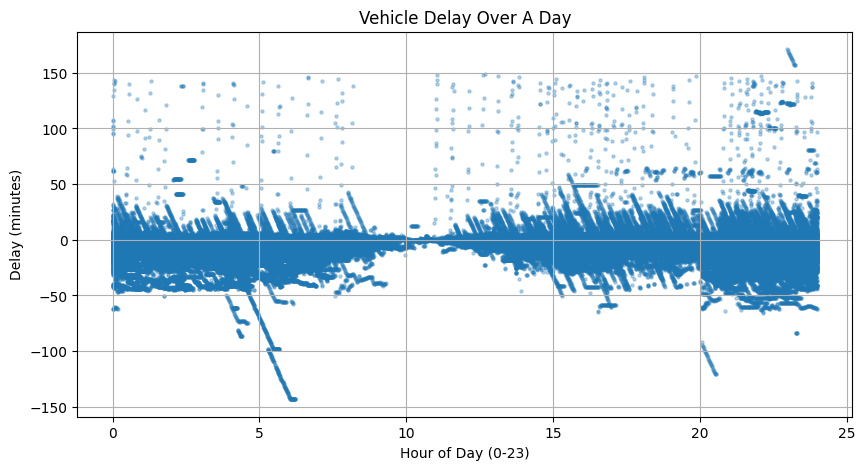

In [22]:

plt.figure(figsize = (10,5))
plt.scatter(df['hour_decimal'], df['delay_minutes'], s=5, alpha = 0.3)
plt.title('Vehicle Delay Over A Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delay (minutes)')
plt.grid(True)
plt.show()

This scatter plot shows that delays almost always within 50 minutes.  Around 10 am, delays are relatively contained at around 0 minutes.  But there is a gradual increase in delays reporting from and towards 10 am mark.  The data is more spread out after 10 am.  

A histogram will help us see what might be the most common delay time is for vehicles.

Text(0.5, 1.0, 'Distribution of Bus Delays')

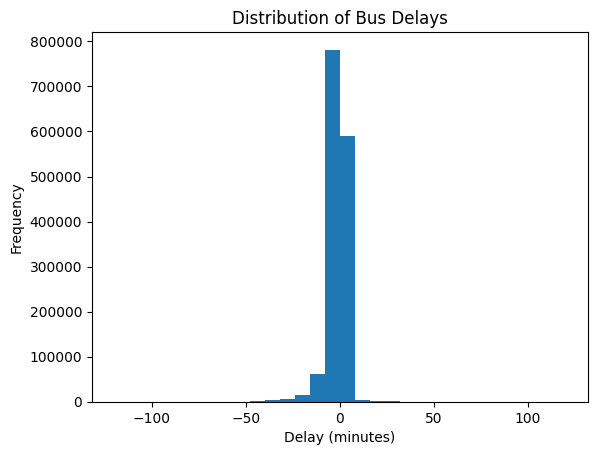

In [23]:
df['delay_minutes'].plot(kind='hist', bins=30, range=(-120, 120))
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Bus Delays")


From the histogram, we can see that the distribution of data is mainly around 0 meaning most of the buses are generally not delayed or early.  There are only some extreme reporting of data going + or - 30 minutes.  So it is probably safe to discard these bad datas as it won't actually have much impact in the end.

Let's actually see how much data will be removed if we cut of delay outliers.

In [24]:
# let's cut off by 30 mins delay or early
cutoff_delay = 30
outliers = df[(df['delay_minutes'] < -cutoff_delay) | (df['delay_minutes'] > cutoff_delay)]
print(outliers['delay_minutes'].describe())
percent_outliers = len(outliers) / len(df) * 100
print(f'{percent_outliers:.2f} % of vehicles is {cutoff_delay} minutes early or late')


count   8875.00
mean     -22.00
std       46.30
min     -143.25
25%      -41.58
50%      -35.27
75%      -31.22
max      171.18
Name: delay_minutes, dtype: float64
0.60 % of vehicles is 30 minutes early or late


After checking the outliers, we can see that only about 7100 rows out of 700,000 have delays over 30 minutes and the standard deviation for the bad outlier is very high meaning there is a lot of spread and delays reports are all over the place.

We can apply the cut off and let's see how it impacts our data.

In [25]:
df = df[(df['delay_minutes'] >= -cutoff_delay) & (df['delay_minutes'] <= cutoff_delay)]

print("Before cleaning delays")
print(df['delay_minutes'].describe())


Before cleaning delays
count   1458968.00
mean         -1.71
std           3.92
min         -30.00
25%          -2.60
50%          -0.52
75%           0.00
max          30.00
Name: delay_minutes, dtype: float64


After cleaning delays:

In [26]:
print("After cleaning delays")
print(df['delay_minutes'].describe())

After cleaning delays
count   1458968.00
mean         -1.71
std           3.92
min         -30.00
25%          -2.60
50%          -0.52
75%           0.00
max          30.00
Name: delay_minutes, dtype: float64


We've dropped about 7000 rows and this significantly lowered our standard deviation from 6.2 to 4.3.  The maximum and minimum value is also now resonable.

## Load Percentage

Let's start off by generating histogram to see data frequency

Text(0.5, 1.0, 'Distribution of Load Percentage')

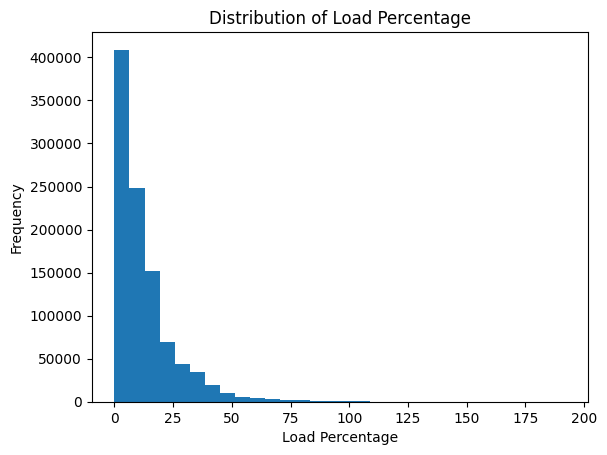

In [27]:
df['loadPercentage'].plot(kind='hist', bins=30)
plt.xlabel("Load Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Load Percentage")


This shows that most data reports below 20% load percentage.
There are some data that reports load percentage over 100%.

*Important Note: Only buses record load percentage so a lot of rows do not have value for load percentage.*

In [28]:
total_load_count = df['loadPercentage'].count()
print(f'There are {len(df)} rows of data but only {total_load_count} rows of load percentage records')

There are 1458968 rows of data but only 1007460 rows of load percentage records


In [29]:
load_cut_off = 100
bad_load = ((df['loadPercentage'] > 100).sum() / total_load_count) * 100

# Let's look into the vehicle with the worst bus load error reports

print(f'{bad_load:.2f}% the data have loadPercentage over 100')
bad_vehicle_load = (
    df[df['loadPercentage'] > 100]
    .groupby('vehicleID')['loadPercentage']
    .count()
    .sort_values(ascending=False)
)

worst_load = bad_vehicle_load.index[0]
# extract only the vehicle with worst load
df_worst_load = df[df['vehicleID'] == worst_load]
df_worst_load.describe()




0.12% the data have loadPercentage over 100


,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,lastLocID,lastStopSeq,latitude,loadPercentage,...,messageCode,nextLocID,nextStopSeq,routeNumber,time,tripID,vehicleID,hour,delay_minutes,hour_decimal
count,1498.00,1498.00,1498,1498.00,1498.00,0.00,1222.00,1222.00,1498.00,1498.00,...,1498.00,1498.00,1498.00,1498.00,1498,1498.00,1498.00,1498.00,1498.00,1498.00
mean,177.32,5095.61,2025-10-20 02:35:38.781709056,-59.67,0.49,NaN,7442.55,40.82,45.48,47.70,...,636.60,7930.11,34.30,74.09,2025-10-20 02:35:32.895137536,15659480.61,3563.00,10.65,-0.99,11.14
min,0.00,1603.00,2025-10-18 20:03:09,-1789.00,0.00,NaN,21.00,1.00,45.32,0.00,...,288.00,21.00,1.00,16.00,2025-10-18 20:03:00.828000,15649786.00,3563.00,0.00,-29.82,0.00
25%,90.00,3303.00,2025-10-19 02:20:28,-113.00,0.00,NaN,3507.50,16.00,45.44,25.00,...,428.00,3727.25,4.00,33.00,2025-10-19 02:20:24.503000064,15653423.00,3563.00,2.00,-1.88,2.75
50%,174.00,3310.00,2025-10-20 00:07:46,-11.00,0.00,NaN,7535.00,37.00,45.45,42.00,...,678.00,7957.00,26.00,72.00,2025-10-20 00:07:39.492999936,15660129.00,3563.00,5.00,-0.18,5.27
75%,270.00,7504.00,2025-10-20 23:22:34,10.00,1.00,NaN,10325.00,64.00,45.55,57.00,...,766.00,11927.00,57.00,75.00,2025-10-20 23:22:29.407499776,15661624.00,3563.00,21.00,0.17,21.97
max,359.00,7504.00,2025-10-23 22:02:04,384.00,1.00,NaN,14655.00,118.00,45.60,158.00,...,870.00,14651.00,119.00,155.00,2025-10-23 22:01:56.012000,15668357.00,3563.00,23.00,6.40,23.98
std,105.15,2156.25,NaN,167.81,0.50,NaN,3978.02,30.22,0.08,33.16,...,177.92,4159.64,31.55,43.90,NaN,5608.77,0.00,9.51,2.80,9.55


Using a scatter plot we can see the trend of how load percentage is reported in a day for the worst bus.

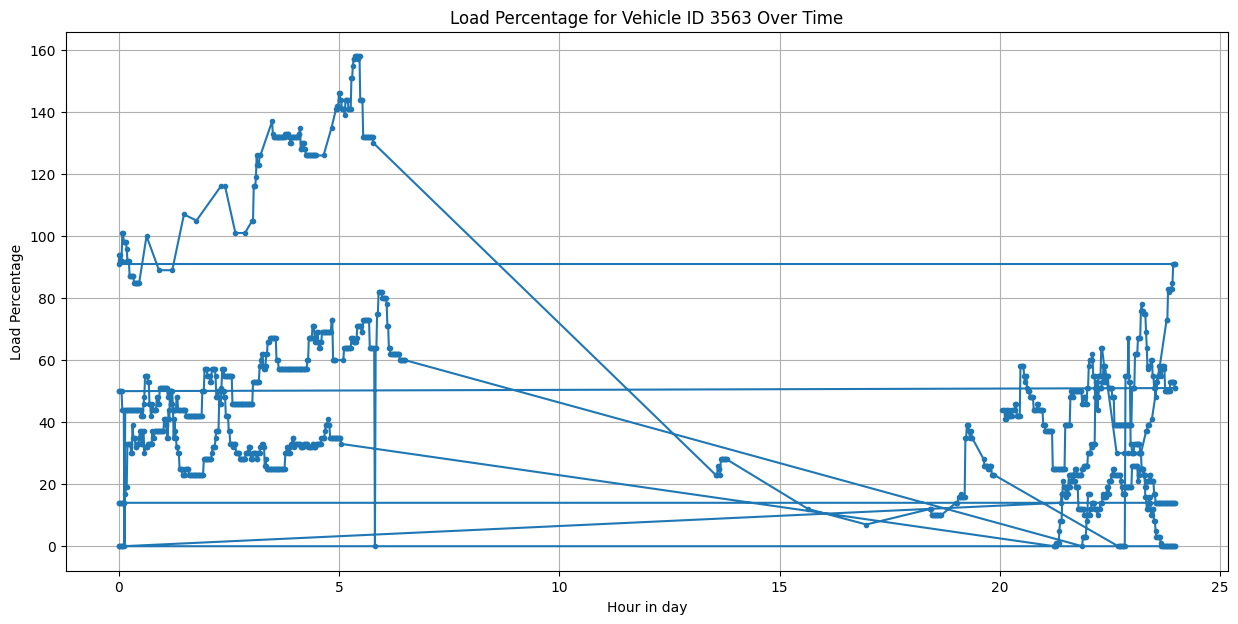

In [30]:
plt.figure(figsize = (15,7))
plt.plot(df_worst_load['hour_decimal'], df_worst_load['loadPercentage'], marker='.', linestyle = '-')
plt.title(f'Load Percentage for Vehicle ID {worst_load} Over Time')
plt.xlabel("Hour in day")
plt.ylabel("Load Percentage")
plt.grid(True)


This graph does really tell a lot about the load percentage for this specific vehicle.  The bad data usually occurs around midnight when the bus is most likely out of service.  During the day, the bus does not report data on load percentage until about 6pm.  This is very interesting but it also raises a lot more questions about what might be affecting this.

Since very low amount of data reports over 100 load percentage and it doesn't make sense that load percentage goes over 100, we've chosen to drop anything over 100 load percentage since it most likely comes from erroneous collection of data.

In [31]:
print(df['loadPercentage'].describe())
df = df[df['loadPercentage'] <= 100]
df['loadPercentage'].describe()

count   1007460.00
mean         12.05
std          13.79
min           0.00
25%           3.00
50%           8.00
75%          17.00
max         192.00
Name: loadPercentage, dtype: float64


count   1006255.00
mean         11.92
std          13.29
min           0.00
25%           3.00
50%           8.00
75%          17.00
max         100.00
Name: loadPercentage, dtype: float64

We've removed about 1000 rows of data.

# Insightful Questions and Conclusion

Now that we've finished some data cleaning, we can start more in depth analysis of the data to create better insights on public transportation system throughout the day.

### Does rush hour impact on time performance

The first obvious thing to look at is what is the impact of bus delays during rush hour.

We will define rush hour the time period at 7-9 AM and 4-6 PM.

In [32]:
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekday = df['day'].isin(weekday_names)

morning_rush = (df['hour'] >= 7) & (df['hour'] <9)
evening_rush = (df['hour'] >= 16) & (df['hour'] <18)

df['is_rush_hour'] = weekday & (morning_rush | evening_rush)

df['is_rush_hour'].value_counts()
df['is_rush_hour'].info()

<class 'pandas.core.series.Series'>
Index: 1006255 entries, 0 to 1467751
Series name: is_rush_hour
Non-Null Count    Dtype
--------------    -----
1006255 non-null  bool 
dtypes: bool(1)
memory usage: 8.6 MB


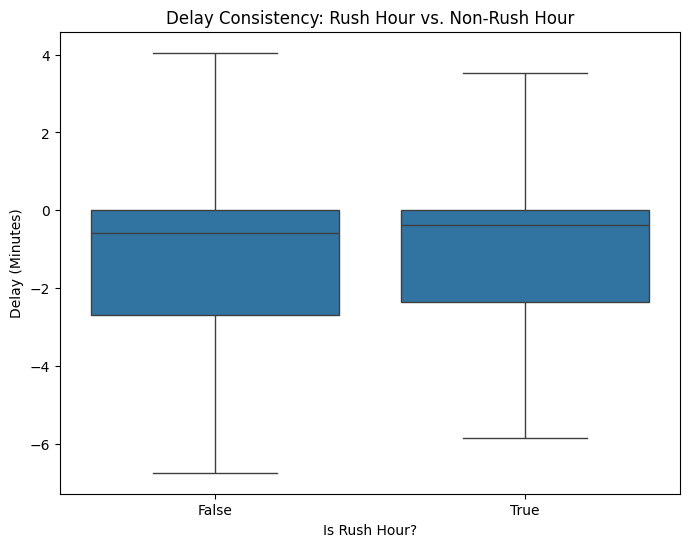

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_rush_hour', y='delay_minutes', showfliers=False) 
plt.title('Delay Consistency: Rush Hour vs. Non-Rush Hour')
plt.ylabel('Delay (Minutes)')
plt.xlabel('Is Rush Hour?')
plt.show()

In [34]:
rush_hour_stats = df.groupby('is_rush_hour')['delay_minutes'].agg(['mean', 'std', 'count'])
rush_hour_stats.index = ['Non-Rush Hour', 'Rush Hour']

print(rush_hour_stats)

std_dev_rush_hour = rush_hour_stats.loc['Rush Hour', 'std']
std_dev_non_rush_hour = rush_hour_stats.loc['Non-Rush Hour', 'std']
print(f'deviation rush hour: ${std_dev_rush_hour}')
print(f'deviation non rush hour: ${std_dev_non_rush_hour}')

               mean  std   count
Non-Rush Hour -1.65 3.80  899868
Rush Hour     -1.40 3.54  106387
deviation rush hour: $3.5351881150741877
deviation non rush hour: $3.7986869606831624


From this, it is surprising to see that the average delay during rush hour and rush hour. The average delay is even less during rush hour which is contradary with original assumptions.

### What is the most congested hour

In [35]:
hourly_congestion = df.groupby('hour')['inCongestion'].mean() * 100

most_congested_hour = hourly_congestion.idxmax()

print(f"The hour wihth the most congestion is : {most_congested_hour}:00")
print(f"At this time, {hourly_congestion.max():.1f}% of vehicles report being in congestion.")

print(hourly_congestion.sort_values(ascending=False).head(5))

The hour wihth the most congestion is : 18:00
At this time, 1.2% of vehicles report being in congestion.
hour
18   1.18
16   1.11
7    1.01
6    0.96
17   0.94
Name: inCongestion, dtype: object


6pm is the time where most vehicles reported inCongestion which is what is expected.  The next following is 4pm and 7 and 6 am which is actually rush hour.  However, only very little vehicle reported inCongestion during this time.

### How does Congestion impact on time performance.

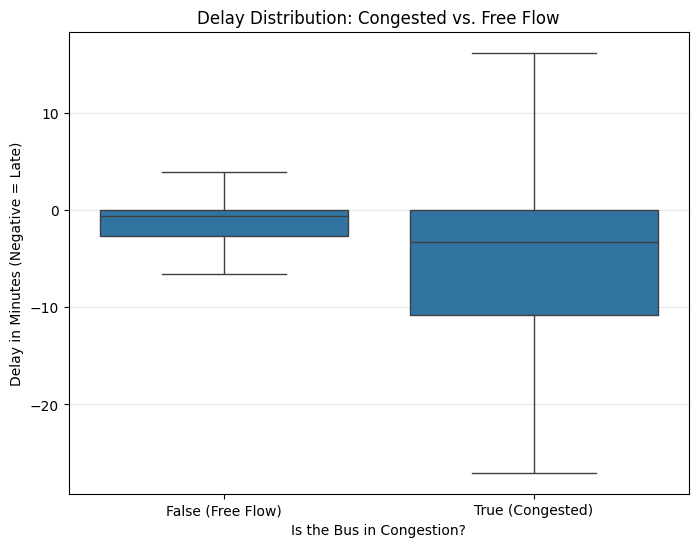

In [36]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='inCongestion', y='delay_minutes', showfliers=False)

plt.title('Delay Distribution: Congested vs. Free Flow')
plt.xlabel('Is the Bus in Congestion?')
plt.ylabel('Delay in Minutes (Negative = Late)')
plt.xticks([0, 1], ['False (Free Flow)', 'True (Congested)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

### What route is most likely to be delayed?

In [71]:
route_performance = df.groupby('routeNumber')['delay_minutes'].agg(['mean','std', 'count'])
print(route_performance.sort_values(by='mean', ascending=True).head(5))
print(route_performance.sort_values(by='mean', ascending=False).head(5))

             mean  std  count
routeNumber                  
293         -7.46 4.15    156
32          -3.80 4.81   4107
12          -2.74 4.77  32836
1           -2.69 3.20    461
15          -2.68 4.65  34325
             mean  std  count
routeNumber                  
98           0.65 3.73   6403
55           0.39 1.94    113
63          -0.06 5.00   1034
58          -0.14 3.15   3736
56          -0.27 2.45   9410


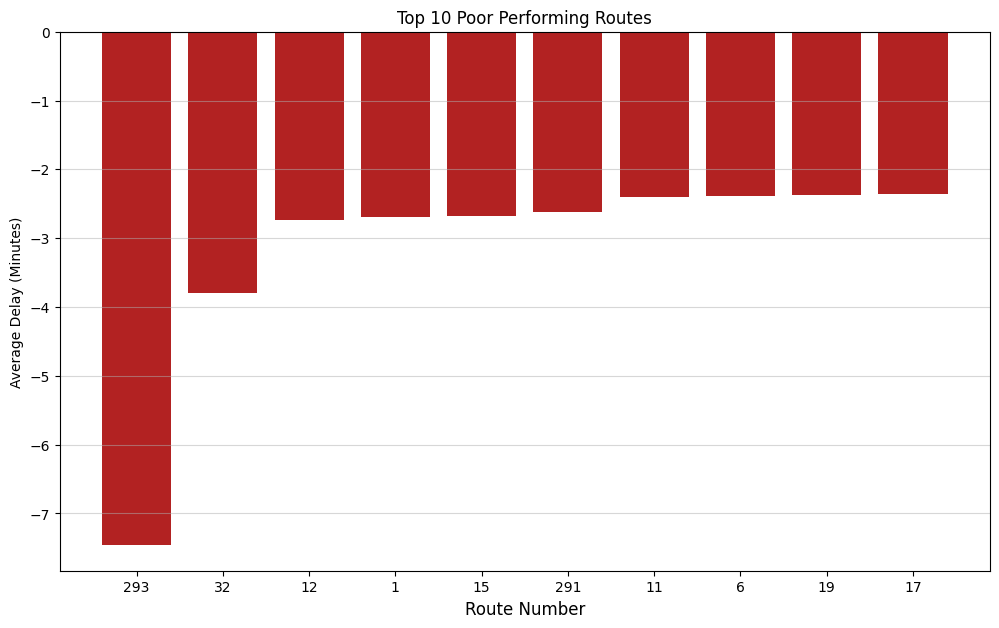

In [55]:
# prepare for visualization resetting index
worst_route_mean = route_performance.sort_values(by='mean').head(10).reset_index()

plt.figure(figsize=(12,7))
plt.bar(worst_route_mean['routeNumber'].astype(str), worst_route_mean['mean'], color='firebrick')
plt.title('Top 10 Poor Performing Routes')
plt.xlabel('Route Number', fontsize=12)
plt.ylabel('Average Delay (Minutes)')
plt.grid(axis='y', alpha=0.5)
plt.show()


### Let's do the samething for best performance

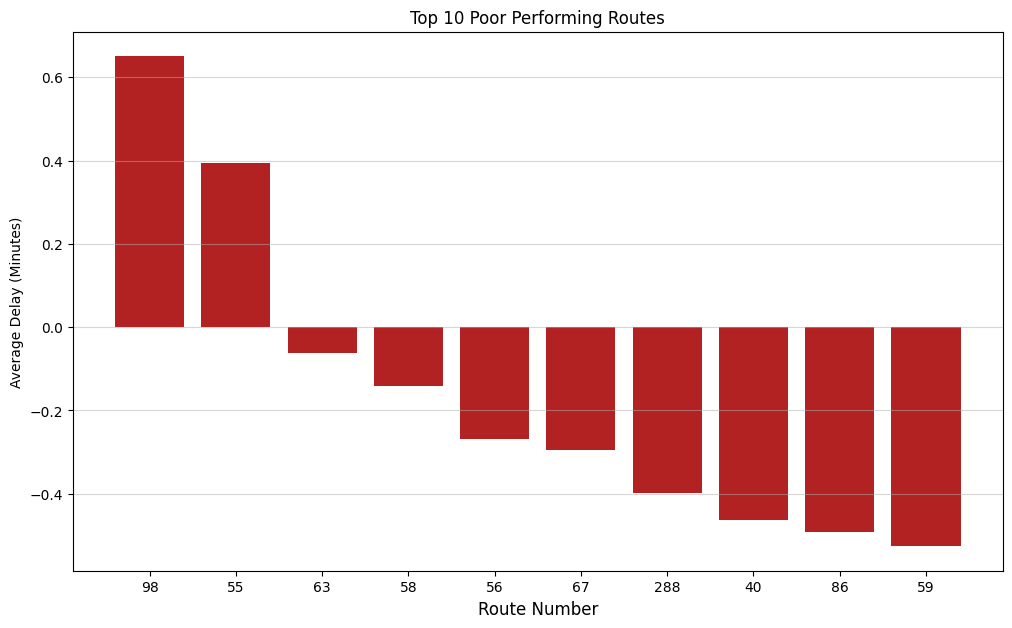

In [57]:
# prepare for visualization resetting index
best_route_mean= route_performance.sort_values(by='mean', ascending=False).head(10).reset_index()

plt.figure(figsize=(12,7))
plt.bar(best_route_mean['routeNumber'].astype(str),best_route_mean['mean'], color='firebrick')
plt.title('Top 10 Poor Performing Routes')
plt.xlabel('Route Number', fontsize=12)
plt.ylabel('Average Delay (Minutes)')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [69]:
## Filter out the best and worst from dataframe
worst_route = route_performance['mean'].idxmin()
best_route = route_performance['mean'].idxmax()

df_route_performance = df[df['routeNumber'].isin([worst_route,best_route])].copy()


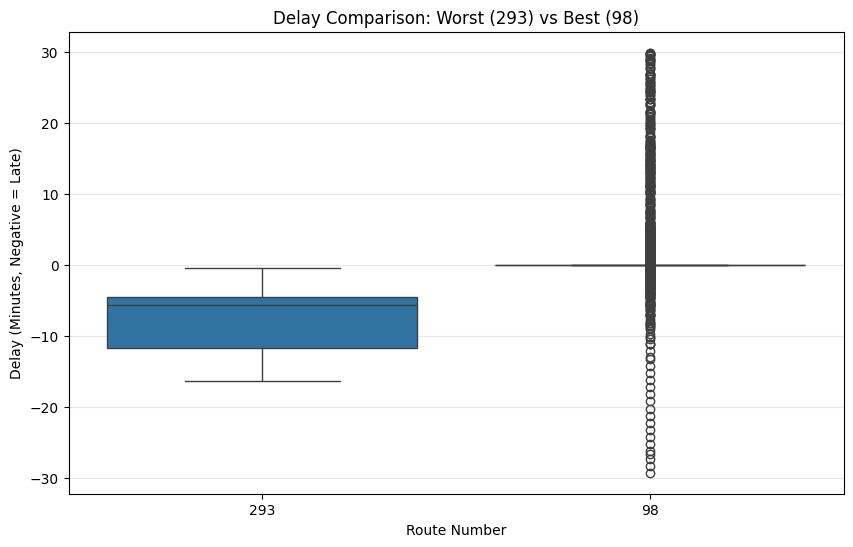

In [ ]:
df['routeLabel'] = df['routeNumber'].astype(str)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='routeLabel',
    y='delay_minutes',
    order=[str(worst_route), str(best_route)]
)

plt.title(f'Delay Comparison: Worst ({worst_route}) vs Best ({best_route})')
plt.xlabel('Route Number')
plt.ylabel('Delay (Minutes, Negative = Late)')
plt.grid(axis='y', alpha = 0.3)


In [79]:
df_98 = df[df['routeNumber'] == 98].copy()
print(f"Subtypes found: {df_98['routeSubType'].unique()}")
print(df_98.sort_values(by='delay_minutes', ascending=False)[['delay_minutes', 'hour', 'day']].head(5))
print(df_98.sort_values(by='delay_minutes', ascending=True)[['delay_minutes', 'hour', 'day']].head(5))

Subtypes found: ['Shuttle']
         delay_minutes  hour       day
1234347          29.95     6  Thursday
926271           29.85    22   Tuesday
1377824          29.82    13  Thursday
844536           29.73     7   Tuesday
659721           29.70    16    Monday
        delay_minutes  hour      day
838270         -29.22     5  Tuesday
838044         -28.22     5  Tuesday
837818         -27.22     5  Tuesday
844215         -26.55     6  Tuesday
837592         -26.20     5  Tuesday
